# Milestone 3: Complete Implementation
**Project:** Data Mining Project (CS 4412)  
**Context:** This notebook implements the preprocessing, exploratory data analysis (EDA), and preliminary association rule mining for the Goodreads 2017 dataset.

**Dataset:** [Goodreads Dataset Source](https://cseweb.ucsd.edu/~jmcauley/datasets/goodreads.html)

### Core Objectives
1. **Genre Association Discovery:** Identify hidden relationships between user-defined "shelves" using FP-Growth.
2. **Engagement Analysis:** Quantify the relationship between ratings, review length, and social interaction (votes/comments).
3. **Data Refinement:** Clean and filter the 2.36M book metadata records and 15.7M reviews into a high-quality "Romantasy" and Romance subset.

# Section 1: Preprocessing and Data Transformation
The raw Goodreads dataset is multi-gigabyte and contains significant noise. We implement a two-stage filtering pipeline:

1. **Language Filtering:** Using the `pycld2` package to ensure a monolingual English dataset.
2. **Genre Targeting:** Extracting records associated with 'Romantasy' and related sub-genres.
3. **Tag Cleaning:** Removing administrative tags (e.g., 'to-read', 'owned', 'kindle') that skew frequency distributions without providing categorical value.

In [1]:
import os
import json
import gzip
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pycld2 as cld2
from tqdm import tqdm
import seaborn as sns
from collections import Counter
from contextlib import ExitStack
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth as mlxtend_fpgrowth
from mlxtend.frequent_patterns import association_rules
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import spacy
import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation



In [ ]:
RAW_REVIEWS_GZ = '../data/goodreads_reviews_dedup.json.gz'
CLEAN_ENGLISH_JSON = '../data/goodreads_reviews_english.json'
#INPUT_FILTERED_JSON = '../data/01_filteredbooks.json'
INPUT_FILTERED_JSON = '../data/01_filteredbooks_noadmin.json'
CLEAN_NOADMIN_JSON = '../data/01_filteredbooks_noadmin.json'
OUTPUT_BOOKS_CSV = '../data/02_extractedbooks.csv'
INPUT_BOOKS_JSON = '../data/01_filteredbooks_noadmin.json'
OUTPUT_REVIEWS_JSON = '../data/03_extractedreviews.json'
OUTPUT_REVIEWS_CSV = '../data/03_extractedreviews.csv'


# --- Global Parameters ---
CHUNK_SIZE = 100000
MIN_SHELF_COUNT = 15
MIN_TAG_COUNT = 10
MIN_SUPPORT = 0.01
MIN_LIFT_THRESHOLD = 2

In [3]:
def is_english(text):
    if not text or len(text.strip()) < 10:
        return False
    try:
        # details[0][1] returns the ISO language code (e.g., 'en')
        is_reliable, _, details = cld2.detect(text)
        return details[0][1] == 'en'
    except Exception:
        return False

def filter_english(input_path, output_path):
    """
    Filters a JSON/JSON.GZ file for English records.
    """
    print(f"Reading from: {input_path}")
    print(f"Writing to:   {output_path}")
    
    os.makedirs(os.path.dirname(output_path) or '.', exist_ok=True)
    
    count = 0
    saved = 0
    open_func = gzip.open if input_path.endswith('.gz') else open

    with open_func(input_path, 'rt', encoding='utf-8') as fin, \
         open(output_path, 'w', encoding='utf-8') as fout:
        for line in fin:
            try:
                record = json.loads(line)
                count += 1
                
                # Check review text first, fallback to title
                texts_to_check = record.get('review_text', record.get('title', ''))

                if is_english(texts_to_check):
                    fout.write(line)
                    saved += 1
                
                if count % 50000 == 0:
                    print(f"Processed {count}... Saved {saved} English records")
            except (json.JSONDecodeError, ValueError):
                continue
                
    print(f"Done! Processed {count} total. Saved {saved} English records.")

# --- How to call it in your notebook ---
RAW_DATA = '../data/goodreads_reviews_dedup.json.gz'
CLEAN_DATA = '../data/goodreads_reviews_english.json'

if os.path.exists(RAW_DATA):
    filter_english(RAW_DATA, CLEAN_DATA)
else:
    print(f"File not found: {RAW_DATA}")

Reading from: ../data/goodreads_reviews_dedup.json.gz
Writing to:   ../data/goodreads_reviews_english.json
Processed 50000... Saved 45302 English records
Processed 100000... Saved 91916 English records
Processed 150000... Saved 137916 English records
Processed 200000... Saved 183852 English records
Processed 250000... Saved 228386 English records
Processed 300000... Saved 273960 English records
Processed 350000... Saved 320313 English records
Processed 400000... Saved 364625 English records
Processed 450000... Saved 410819 English records
Processed 500000... Saved 454098 English records
Processed 550000... Saved 499181 English records
Processed 600000... Saved 545274 English records
Processed 650000... Saved 589492 English records
Processed 700000... Saved 635555 English records
Processed 750000... Saved 680098 English records
Processed 800000... Saved 723922 English records
Processed 850000... Saved 768578 English records
Processed 900000... Saved 814068 English records
Processed 9500

### 1. Create 01_filteredbooks.json and filter out books in the dataset that match Romantasy genres

In [4]:
# 01_filterbooks takes in the books dataset (contains all of the books in goodreads) and saves only romance books to the datset to create a romance subset
def filter_goodreads_data(input_path, output_path, target_keywords):
    """
    Streams a large .json.gz file and filters records based on keywords
    in the 'popular_shelves' attribute.
    """
    print(f"Starting filtration of {input_path}...")
    count = 0
    saved = 0

    # Ensure output directory exists
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    open_func = gzip.open if input_path.endswith('.gz') else open

    with open_func(input_path, 'rt', encoding='utf-8') as fin, \
         open(output_path, 'w', encoding='utf-8') as fout:

        for line in fin:
            count += 1
            book = json.loads(line)
            
            # Extract tags from the popular_shelves list of dictionaries
            # Structure: [{'count': '123', 'name': 'fantasy'}, ...]
            shelves = [s['name'].lower() for s in book.get('popular_shelves', [])]
            
            # Check if any target keywords (like 'romantasy') are in the shelves
            if any(key in " ".join(shelves) for key in target_keywords):
                fout.write(json.dumps(book) + '\n')
                saved += 1
            
            if count % 100000 == 0:
                print(f"Processed {count} books... Saved {saved} matches.")

    print(f"Done! Processed {count} total books. Saved {saved} to {output_path}.")

keywords = ['romantasy', 'romantic-fantasy', 'fantasy-romance', 'romance', 'fantasy', 'romantic']
CLEAN_DATA = '../data/goodreads_books.json.gz'
filter_goodreads_data(CLEAN_DATA, '../data/01_filteredbooks.json', keywords)


Starting filtration of ../data/goodreads_books.json.gz...
Processed 100000 books... Saved 40195 matches.
Processed 200000 books... Saved 80643 matches.
Processed 300000 books... Saved 120979 matches.
Processed 400000 books... Saved 161095 matches.
Processed 500000 books... Saved 200947 matches.
Processed 600000 books... Saved 241024 matches.
Processed 700000 books... Saved 280807 matches.
Processed 800000 books... Saved 321034 matches.
Processed 900000 books... Saved 361130 matches.
Processed 1000000 books... Saved 400974 matches.
Processed 1100000 books... Saved 441115 matches.
Processed 1200000 books... Saved 481218 matches.
Processed 1300000 books... Saved 521627 matches.
Processed 1400000 books... Saved 562036 matches.
Processed 1500000 books... Saved 602079 matches.
Processed 1600000 books... Saved 642473 matches.
Processed 1700000 books... Saved 682581 matches.
Processed 1800000 books... Saved 722562 matches.
Processed 1900000 books... Saved 762467 matches.
Processed 2000000 book

In [5]:


def clean_admin_tags(input_path, output_path, min_count=10):
    """
    1. Filters out 'administrative' tags.
    2. ONLY keeps books that have at least one Romance or Fantasy related tag.
    """
    print(f"Cleaning and Genre-Filtering: {input_path} -> {output_path}")
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    
    # These are the keywords that "qualify" a book for your study
    target_keywords = {'romance', 'fantasy', 'romantasy', 'paranormal', 'supernatural'}
    
    book_count = 0
    generic_tags = {
        'to-read', 'currently-reading', 'owned', 'favorites', 'all-time-favorites', 
        'books-i-own', 'read-in-2017', 'read-in-2016', 'default', 'ebook', 'kindle', 
        'audiobook', 'my-books', 'library', 'wish-list', 'maybe', 'finish', 'read',
        'to-own', 'i-own', 'on-my-shelf', 'dnf', 'my-personal-library', 're-read', 
        'tbr', 'tbr-pile', 'to read', 'currently reading', 'audiobooks', 'my books', 
        'wish list', 'e book', 'hardcover', 'paperback', 'hardback', 'shelfari favorites', 
        'owned books', 'favorite', 'paper', 'hardcopy', 'unfinished', 'duplicates',
        'i own it', 'not read', 'read some day', 'own hard copy', 'in my home library',
        'to-buy', 'audio', 'my library', 'to buy', 'ebooks'
    }

    with open(input_path, 'rt', encoding='utf-8') as fin, \
         open(output_path, 'w', encoding='utf-8') as fout:

        for line in fin:
            try:
                book = json.loads(line)
                raw_shelves = book.get('popular_shelves', [])
                filtered_shelves = []
                is_relevant_genre = False # Track if this book fits your research

                for s in raw_shelves:
                    try:
                        count = int(s.get('count', 0)) if isinstance(s, dict) else 0
                        name = s.get('name', '').strip() if isinstance(s, dict) else str(s).strip()
                    except: continue

                    if count < min_count and isinstance(s, dict):
                        continue

                    # Normalization
                    norm = name.lower().replace('-', ' ').replace('_', ' ').strip()
                    
                    if (norm.startswith('read in') or norm in generic_tags or len(norm) <= 2 or norm.isdigit()):
                        continue

                    # --- THE NEW FILTER ---
                    # Check if the tag contains any of our research keywords
                    if any(kw in norm for kw in target_keywords):
                        is_relevant_genre = True

                    filtered_shelves.append(name.replace(',', ' ').strip())

                # ONLY save the book if it's relevant to Romance/Fantasy
                if is_relevant_genre and len(filtered_shelves) > 1:
                    book['popular_shelves'] = filtered_shelves
                    fout.write(json.dumps(book) + '\n')
                    book_count += 1

                if book_count % 50000 == 0 and book_count > 0:
                    print(f"Found {book_count} relevant Romance/Fantasy books...")
                    
            except (json.JSONDecodeError, ValueError):
                continue
                
    print(f"Done! Saved {book_count} relevant books to {output_path}.")
    
def flatten_shelves(shelves_list):
    if not isinstance(shelves_list, list):
        return ""
    return ", ".join(shelves_list[:10])

def make_books_table(input_json, output_csv):
    """
    Converts the cleaned JSON into a flat CSV for easier EDA.
    """
    print(f"Formatting {input_json} to CSV...")
    try:
        # Using a sample or chunked read is safer for memory
        # If the file is small, we can read all at once:
        df = pd.read_json(input_json, lines=True)
        print(f"Successfully loaded {len(df)} books")

        if 'authors' in df.columns:
            df['primary_author'] = df['authors'].apply(
                lambda x: x[0]['author_id'] if isinstance(x, list) and len(x) > 0 else ""
            )

        if 'popular_shelves' in df.columns:
            df['shelves_list'] = df['popular_shelves'].apply(flatten_shelves)

        cols_to_show = ['book_id', 'title', 'average_rating', 'ratings_count', 'primary_author', 'shelves_list']
        existing_cols = [c for c in cols_to_show if c in df.columns]

        working_df = df[existing_cols]
        working_df.to_csv(output_csv, index=False)
        
        print("\n--- Preview ---")
        print(working_df.head().to_string(index=False))
        print(f"\nSuccess! Readable results saved to: {output_csv}")
    except Exception as e:
        print(f"Failed to load JSON to CSV: {e}")

# --- Execution ---
if os.path.exists('../data/01_filteredbooks.json'):
    # 1. Strip out administrative tags
    clean_admin_tags('../data/01_filteredbooks.json', CLEAN_NOADMIN_JSON, min_count=MIN_SHELF_COUNT)
    
    # 2. Flatten to CSV
    make_books_table(CLEAN_NOADMIN_JSON, OUTPUT_BOOKS_CSV)
else:
    print(f"Error: Could not find {INPUT_FILTERED_JSON}")

Cleaning and Genre-Filtering: ../data/01_filteredbooks.json -> ../data/01_filteredbooks_noadmin.json
Found 50000 relevant Romance/Fantasy books...
Found 50000 relevant Romance/Fantasy books...
Found 50000 relevant Romance/Fantasy books...
Found 100000 relevant Romance/Fantasy books...
Found 100000 relevant Romance/Fantasy books...
Found 100000 relevant Romance/Fantasy books...
Found 100000 relevant Romance/Fantasy books...
Found 100000 relevant Romance/Fantasy books...
Found 150000 relevant Romance/Fantasy books...
Found 150000 relevant Romance/Fantasy books...
Found 150000 relevant Romance/Fantasy books...
Found 150000 relevant Romance/Fantasy books...
Found 150000 relevant Romance/Fantasy books...
Found 200000 relevant Romance/Fantasy books...
Found 200000 relevant Romance/Fantasy books...
Found 200000 relevant Romance/Fantasy books...
Found 200000 relevant Romance/Fantasy books...
Found 250000 relevant Romance/Fantasy books...
Found 250000 relevant Romance/Fantasy books...
Found 300

## 3. ExtractReviews

In [6]:

def filter_reviews(subset_path, review_dataset, output):
    print(f"1. Loading book IDs from {subset_path}...")
    book_ids = set()
    
    if not os.path.exists(subset_path):
        print(f"Error: {subset_path} not found.")
        return False

    with open(subset_path, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                book = json.loads(line)
                book_ids.add(book['book_id'])
            except json.JSONDecodeError:
                continue
                
    print(f"Loaded {len(book_ids)} unique book IDs.")
    print(f"2. Filtering reviews from {review_dataset}...")
    
    count = 0
    saved = 0
    open_func = gzip.open if review_dataset.endswith('.gz') else open
    
    with open_func(review_dataset, mode="rt", encoding='utf-8') as fin, \
         open(output, 'w', encoding='utf-8') as fout:
        for line in fin:
            count += 1
            try:
                review = json.loads(line)
                if review['book_id'] in book_ids:
                    fout.write(json.dumps(review) + '\n')
                    saved += 1
            except json.JSONDecodeError:
                continue
                
            if count % 100000 == 0:
                print(f"Processed {count} reviews... Saved {saved}")
                
    print(f"Done! Saved {saved} reviews to {output}")
    return True

def make_table(filtered_reviews_json, output_csv):
    print(f"3. Converting {filtered_reviews_json} to CSV in chunks...")
    try:
        first_chunk = True
        total_processed = 0
        
        # Using chunksize to keep memory usage low
        for chunk in pd.read_json(filtered_reviews_json, lines=True, chunksize=CHUNK_SIZE):
            if 'review_text' in chunk.columns:
                # Create a clean snippet for the CSV
                chunk['review_snippet'] = (
                    chunk['review_text']
                    .str.replace('\n', ' ', regex=False)
                    .str[:100] + "..."
                )
            
            cols_to_show = ['book_id', 'user_id', 'rating', 'n_votes', 'n_comments', 'review_snippet']
            existing_cols = [c for c in cols_to_show if c in chunk.columns]
            working_df = chunk[existing_cols]
            
            # Write mode: 'w' for the first chunk (overwrite/new), 'a' for subsequent (append)
            mode = 'w' if first_chunk else 'a'
            header = True if first_chunk else False
            
            working_df.to_csv(output_csv, index=False, mode=mode, header=header)
            
            if first_chunk:
                print("\n--- Preview of First 5 Reviews ---")
                print(working_df.head().to_string(index=False))
                first_chunk = False
            
            total_processed += len(working_df)
            
        print(f"\nSuccess! Readable results saved to: {output_csv}")
        return True
    except Exception as e:
        print(f"Failed to process CSV: {e}")
        return False

# --- Execution ---
# Ensure the data directory exists
os.makedirs(os.path.dirname(OUTPUT_REVIEWS_JSON), exist_ok=True)

# Run the pipeline
if os.path.exists(RAW_REVIEWS_GZ):
    success = filter_reviews(INPUT_BOOKS_JSON, RAW_REVIEWS_GZ, OUTPUT_REVIEWS_JSON)
    if success:
        make_table(OUTPUT_REVIEWS_JSON, OUTPUT_REVIEWS_CSV)
else:
    print(f"Error: Review dataset not found at {RAW_REVIEWS_GZ}")

1. Loading book IDs from ../data/01_filteredbooks_noadmin.json...
Loaded 334666 unique book IDs.
2. Filtering reviews from ../data/goodreads_reviews_dedup.json.gz...
Processed 100000 reviews... Saved 47329
Processed 200000 reviews... Saved 97306
Processed 300000 reviews... Saved 148091
Processed 400000 reviews... Saved 197383
Processed 500000 reviews... Saved 245157
Processed 600000 reviews... Saved 292744
Processed 700000 reviews... Saved 337183
Processed 800000 reviews... Saved 385411
Processed 900000 reviews... Saved 432711
Processed 1000000 reviews... Saved 480842
Processed 1100000 reviews... Saved 526917
Processed 1200000 reviews... Saved 575346
Processed 1300000 reviews... Saved 618948
Processed 1400000 reviews... Saved 666106
Processed 1500000 reviews... Saved 713185
Processed 1600000 reviews... Saved 763631
Processed 1700000 reviews... Saved 811598
Processed 1800000 reviews... Saved 854478
Processed 1900000 reviews... Saved 903362
Processed 2000000 reviews... Saved 952667
Proce

# Section 3: Answering Discovery Question 1 (Genre Associations)
Using the **FP-Growth algorithm**, we treat each user's "shelves" as a transaction. Our goal is to identify which sub-genres are most frequently "cross-pollinated" by readers. 

* **Algorithm:** FP-Growth
* **Metrics:** Support, Confidence, and Lift


In [7]:

# --- Configuration ---
INPUT_JSON = '../data/01_filteredbooks_noadmin.json'
TEMP_TRANSACTIONS = '../data/04_temp.csv'
OUTPUT_RULES = '../data/04_association.csv'

def normalize_tags(tag):
    """Merges messy user tags into clean research categories."""
    tag = tag.lower().replace('-', ' ').strip()
    
    # Define your "Discovery" Map
    mapping = {
        'romantasy': 'romantasy',
        'fantasy romance': 'romantasy',
        'romance fantasy': 'romantasy',
        'paranormal romance': 'paranormal-romance',
        'pnr': 'paranormal-romance',
        'urban fantasy': 'urban-fantasy',
        'high fantasy': 'epic-fantasy',
        'epic fantasy': 'epic-fantasy',
        'ya fantasy': 'young-adult-fantasy',
        'young adult fantasy': 'young-adult-fantasy'
    }
    return mapping.get(tag, tag)
    
def extract_shelf_transactions(input_path, output_path, min_count=10):
    print(f"Extracting transactions from {input_path}...")
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    
    book_count = 0
    generic_tags = {
        'to-read', 'currently-reading', 'owned', 'favorites', 'books-i-own', 
        'ebook', 'kindle', 'audiobook', 'my-books', 'library', 'read', 'tbr',
        'hardcover', 'paperback', 'default', 'wish-list', 'dnf', 'audio'
  }

    open_func = gzip.open if input_path.endswith('.gz') else open
    
    with open_func(input_path, 'rt', encoding='utf-8') as fin, \
         open(output_path, 'w', encoding='utf-8') as fout:
        for line in tqdm(fin, desc="Processing Books"):
            try:
                book = json.loads(line)
                shelves = []
                for s in book.get('popular_shelves', []):
                    if isinstance(s, dict):
                        if int(s.get('count', 0)) >= min_count:
                            shelves.append(s.get('name', '').replace(',', ' ').strip())
                    elif isinstance(s, str):
                        shelves.append(s.replace(',', ' ').strip())
                
                # Filter out the generic noise
                filtered_shelves = [s for s in shelves if s.lower() not in generic_tags]

                if len(filtered_shelves) > 1:
                    fout.write(",".join(filtered_shelves) + '\n')
                    book_count += 1
                
                if book_count % 100000 == 0 and book_count > 0:
                    print(f"Streamed {book_count} books...")
            except (json.JSONDecodeError, ValueError):
                continue
                
    print(f"Done! Saved {book_count} transactions to {output_path}.")

def run_association_mining(transaction_file, min_support=0.01, min_threshold=0.01):
    print(f"Loading transactions from {transaction_file} into memory...")
    if not os.path.exists(transaction_file):
        print("Transaction file not found.")
        return None, None

    with open(transaction_file, 'r', encoding='utf-8') as f:
        dataset = [line.strip().split(',') for line in f if line.strip()]

    if not dataset:
        print("No transactions found.")
        return None, None

    print(f"Encoding {len(dataset)} transactions into a Sparse Matrix...")
    te = TransactionEncoder()
    te_ary = te.fit(dataset).transform(dataset, sparse=True)
    df = pd.DataFrame.sparse.from_spmatrix(te_ary, columns=te.columns_)

    del dataset
    gc.collect()

    print(f"Running FP-Growth (min_support={min_support})...")
    frequent_itemsets = mlxtend_fpgrowth(
        df, 
        min_support=MIN_SUPPORT, 
        use_colnames=True, 
        max_len=3
    )

    if frequent_itemsets.empty:
        print("No frequent itemsets found. Try lowering min_support.")
        return None, None

    print("Generating association rules...")
    rules = association_rules(frequent_itemsets, metric="lift", min_threshold=min_threshold)
    rules = rules.sort_values(by="lift", ascending=False)
    return frequent_itemsets, rules

# --- Execution ---
if os.path.exists(INPUT_JSON):
    # 1. Process the JSON into a CSV of shelf 'transactions'
    extract_shelf_transactions(INPUT_JSON, TEMP_TRANSACTIONS, min_count=MIN_SHELF_COUNT)
    
    # 2. Run the mining algorithm
    itemsets, rules = run_association_mining(
        TEMP_TRANSACTIONS, 
        min_support=MIN_SUPPORT, 
        min_threshold=MIN_LIFT_THRESHOLD
    )

    # 3. Display Results
    if rules is not None:
        romantasy_rules = rules[
            rules['antecedents'].apply(lambda x: 'romantasy' in x) | 
            rules['consequents'].apply(lambda x: 'romantasy' in x)
        ].sort_values(by="lift", ascending=False)

        print("\n--- Discovery: Romantasy Cross-Pollination ---")
        if not romantasy_rules.empty:
            # Clean up the display for the notebook
            display_df = romantasy_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15).copy()
            display_df['antecedents'] = display_df['antecedents'].apply(lambda x: list(x))
            display_df['consequents'] = display_df['consequents'].apply(lambda x: list(x))
            print(display_df)
        else:
            print("No Romantasy-specific rules found. Try lowering MIN_SUPPORT.")
        rules.to_csv(OUTPUT_RULES, index=False)
        print(f"\nFull results saved to {OUTPUT_RULES}")
else:
    print(f"Error: Could not find input file at {INPUT_JSON}")

Extracting transactions from ../data/01_filteredbooks_noadmin.json...


Processing Books: 107454it [00:02, 40947.90it/s]

Streamed 100000 books...


Processing Books: 206203it [00:05, 40917.60it/s]

Streamed 200000 books...


Processing Books: 307189it [00:07, 39672.84it/s]

Streamed 300000 books...


Processing Books: 334666it [00:08, 40567.95it/s]


Done! Saved 334588 transactions to ../data/04_temp.csv.
Loading transactions from ../data/04_temp.csv into memory...
Encoding 334588 transactions into a Sparse Matrix...
Running FP-Growth (min_support=0.01)...
Generating association rules...

--- Discovery: Romantasy Cross-Pollination ---
No Romantasy-specific rules found. Try lowering MIN_SUPPORT.

Full results saved to ../data/04_association.csv


### Generate Assoication Graph

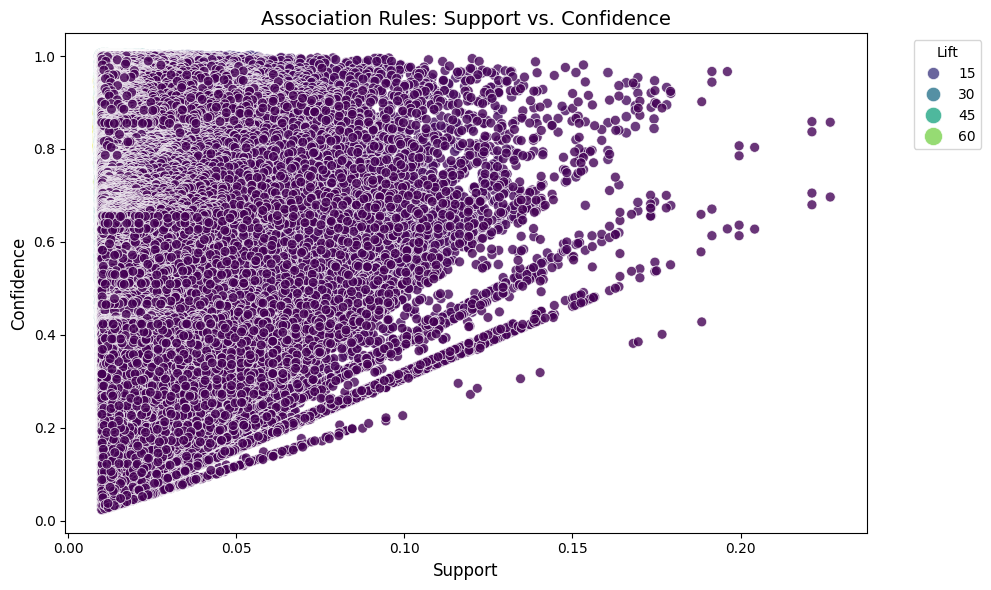

In [8]:
# --- scripts/06_associationgraph.py ---


input_fil = '../data/04_association.csv'
df_rules = pd.read_csv(input_fil)

plt.figure(figsize=(10, 6))

scatter = sns.scatterplot(
    data=df_rules,
    x='support',
    y='confidence',
    hue='lift',
    palette='viridis', 
    size='lift',       
    sizes=(50, 200),
    alpha=0.8
)

plt.title('Association Rules: Support vs. Confidence', fontsize=14)
plt.xlabel('Support', fontsize=12)
plt.ylabel('Confidence', fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Lift')
plt.tight_layout()
plt.savefig('scatter_association_rules.png')
plt.show()

# Section 2: Exploratory Data Analysis

These were just various scripts that I made to see some figures. Right now I may or may not use them in the report.
### 2.1 Distribution of Ratings
We examine the average rating distribution to establish a baseline. Initial findings suggest that romance readers are generally positive, with a rating density peaking around 4.0.

### 2.2 Engagement Volume & Correlation Analysis
We perform a Pearson correlation analysis across four key metrics: `rating`, `n_votes`, `n_comments`, and `review_length`. 
* **Key Hypothesis:** Does review length or rating sentiment drive community interaction?

### 5. Create Histogram

Loading data from ../data/02_extractedbooks.csv...


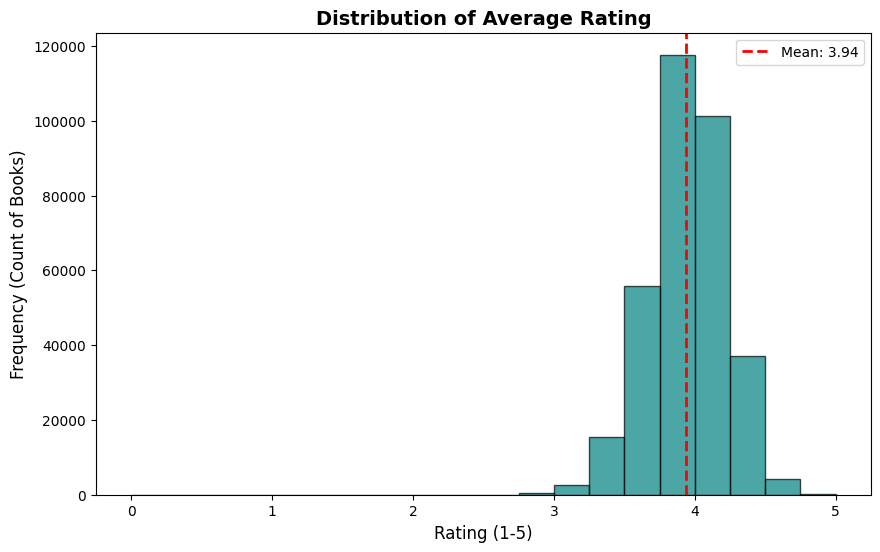

Success! Histogram saved to ../docs/rating_histogram.png


In [9]:


# --- Configuration ---
# Set these to match your actual file names
INPUT_DATA = '../data/02_extractedbooks.csv'  # The CSV created in the previous step
OUTPUT_PLOT = '../docs/rating_histogram.png'

def generate_histogram(input_path, output_path, column_name='average_rating'):
    """
    Generates a rating distribution histogram from a CSV file.
    """
    if not os.path.exists(input_path):
        print(f"Error: File {input_path} does not exist.")
        return

    print(f"Loading data from {input_path}...")
    df = pd.read_csv(input_path)
    
    # Check if the requested column exists, otherwise look for 'rating'
    if column_name not in df.columns and 'rating' in df.columns:
        column_name = 'rating'
    
    if column_name not in df.columns:
        print(f"Error: Could not find '{column_name}' or 'rating' columns in the dataset.")
        return

    # Set up the visual style
    plt.figure(figsize=(10, 6))
    df[column_name].hist(
        bins=20,
        color="#008080",
        edgecolor='black',
        grid=False,
        alpha=0.7
    )
    
    # Calculate statistics for the legend
    mean_val = df[column_name].mean()
    median_val = df[column_name].median()
    
    # Visual cues
    plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.2f}')
    
    # Formatting
    title = column_name.replace('_', ' ').title()
    plt.title(f'Distribution of {title}', fontsize=14, fontweight='bold')
    plt.xlabel('Rating (1-5)', fontsize=12)
    plt.ylabel('Frequency (Count of Books)', fontsize=12)
    plt.legend()

    # Save and show
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Success! Histogram saved to {output_path}")

def generate_histogram_from_json(input_path, output_path, key_name='average_rating'):
    """
    Utility to generate a histogram directly from a JSON or JSON.GZ file 
    (Useful for raw data before it is converted to CSV).
    """
    if not os.path.exists(input_path):
        print(f"Error: File {input_path} not found.")
        return

    data_points = []
    count = 0
    open_func = gzip.open if input_path.endswith('.gz') else open
    
    print(f"Streaming data from {input_path}...")
    with open_func(input_path, 'rt', encoding='utf-8') as fin:
        for line in fin:
            try:
                record = json.loads(line)
                # Fixed the 'avarage' typo from the original script
                value = record.get(key_name)
                if value is not None:
                    data_points.append(float(value))
                
                count += 1
                if count % 100000 == 0:
                    print(f"Processed {count} records...")
            except (json.JSONDecodeError, ValueError):
                continue

    if not data_points:
        print("No valid rating data found.")
        return

    plt.figure(figsize=(10, 6))
    plt.hist(data_points, bins=40, color="#008080", edgecolor='black', alpha=0.7)
    
    plt.title(f'Ratings Distribution (Raw JSON)', fontsize=14, fontweight='bold')
    plt.xlabel(key_name.replace('_', ' ').title(), fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(axis='y', alpha=0.3)

    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

# --- Execution ---
# Use this for the CSV output of your previous scripts
generate_histogram(INPUT_DATA, OUTPUT_PLOT)

# OR: Use this if you want to plot directly from a raw JSON/GZ file
# generate_histogram_from_json('../data/01_filteredbooks.json', '../docs/raw_histogram.png')

### 6. Create Bar Geaph

Reading ../data/01_filteredbooks_noadmin.json to measure tag frequencies...


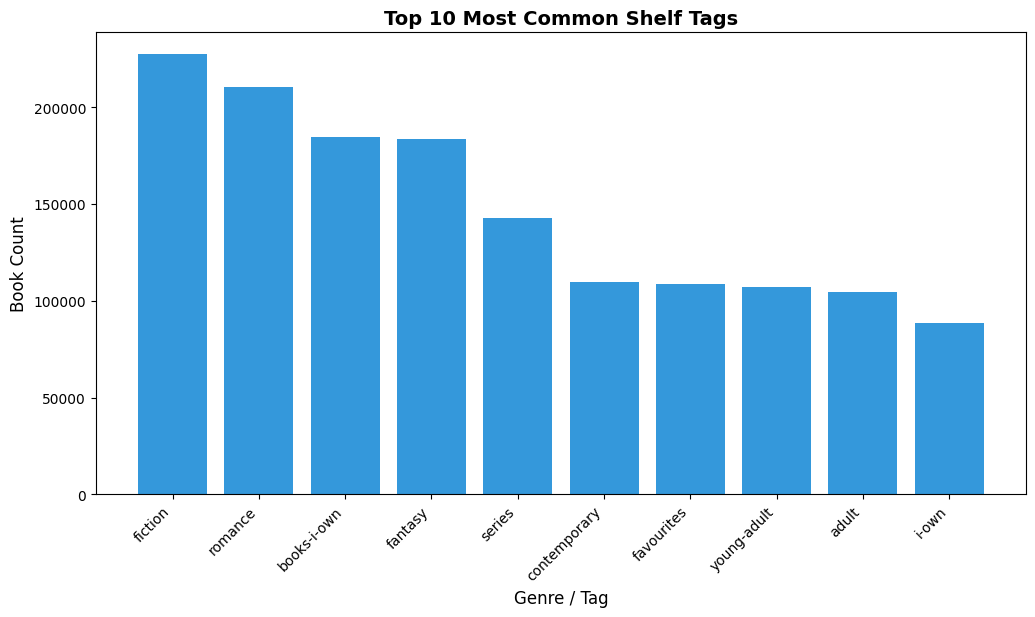


TOP 15 DISCOVERED ATTRIBUTES (SHELF TAGS)
               Tag  Book Count
           fiction      227242
           romance      210211
       books-i-own      184670
           fantasy      183713
            series      142998
      contemporary      109491
        favourites      108880
       young-adult      107053
             adult      104469
             i-own       88441
            novels       85032
        paranormal       77644
           mystery       70761
         adventure       69930
historical-fiction       69091
Results saved to ../data/06_tags.csv


In [10]:
import pandas as pd 
import json 
import os
from collections import Counter
import matplotlib.pyplot as plt

# --- Configuration ---
# Update these paths to match your project structure
INPUT_JSON = '../data/01_filteredbooks_noadmin.json'
OUTPUT_CSV = '../data/06_tags.csv'
OUTPUT_PLOT = '../docs/10commonbargraph.png'

def generate_tag_frequency(input_path, csv_path, plot_path, top_n=10):
    """
    Analyzes shelf tag frequency and generates a bar graph of the top genres.
    """
    if not os.path.exists(input_path):
        print(f"Error: Input file {input_path} not found.")
        return

    tags_counts = Counter()
    print(f"Reading {input_path} to measure tag frequencies...")
    
    with open(input_path, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                book = json.loads(line)
                shelves = book.get('popular_shelves', [])
                tags = []
                for s in shelves:
                    # Robust handling for both dict and string tag formats
                    if isinstance(s, dict):
                        tags.append(s['name'].lower().strip())
                    elif isinstance(s, str):
                        tags.append(s.lower().strip())
                tags_counts.update(tags)
            except json.JSONDecodeError:
                continue
                
    # Create DataFrame of the most common tags
    df = pd.DataFrame(tags_counts.most_common(50), columns=['Tag', 'Book Count'])
    top_tags = df.head(top_n)
    
    # --- Visualization ---
    plt.figure(figsize=(12, 6))
    plt.bar(top_tags['Tag'], top_tags['Book Count'], color='#3498db')
    
    plt.title(f'Top {top_n} Most Common Shelf Tags', fontsize=14, fontweight='bold')
    plt.xlabel('Genre / Tag', fontsize=12)
    plt.ylabel('Book Count', fontsize=12)
    
    # Rotate labels to prevent overlap
    plt.xticks(rotation=45, ha='right')
    
    # Ensure directories exist before saving
    os.makedirs(os.path.dirname(plot_path), exist_ok=True)
    os.makedirs(os.path.dirname(csv_path), exist_ok=True)
    
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.show()

    # Save full frequency list to CSV
    df.to_csv(csv_path, index=False)
    
    print("\n" + "="*45)
    print(f"TOP 15 DISCOVERED ATTRIBUTES (SHELF TAGS)")
    print("="*45)
    print(df.head(15).to_string(index=False))
    print("="*45)
    print(f"Results saved to {csv_path}")

# --- Execution ---
generate_tag_frequency(INPUT_JSON, OUTPUT_CSV, OUTPUT_PLOT, top_n=10)

### 6. Generate Heatmap

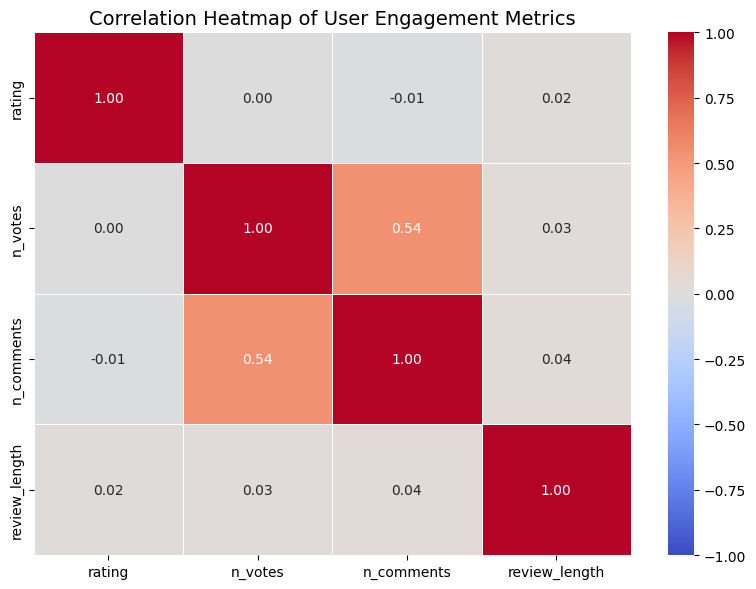

In [11]:
# --- scripts/07_heatmap.py ---
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_reviews = pd.read_csv('../data/03_extractedreviews.csv')

if 'review_length' not in df_reviews.columns:
    df_reviews['review_length'] = df_reviews['review_snippet'].astype(str).apply(len)

numeric_cols = ['rating', 'n_votes', 'n_comments', 'review_length']
df_numeric = df_reviews[numeric_cols]

corr_matrix = df_numeric.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap of User Engagement Metrics', fontsize=14)
plt.tight_layout()

plt.savefig('../docs/correlation_heatmap.png')
plt.show()

### 8. Generate scatterplot

/tmp/ipykernel_4332/2648539853.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  scatter = sns.scatterplot(


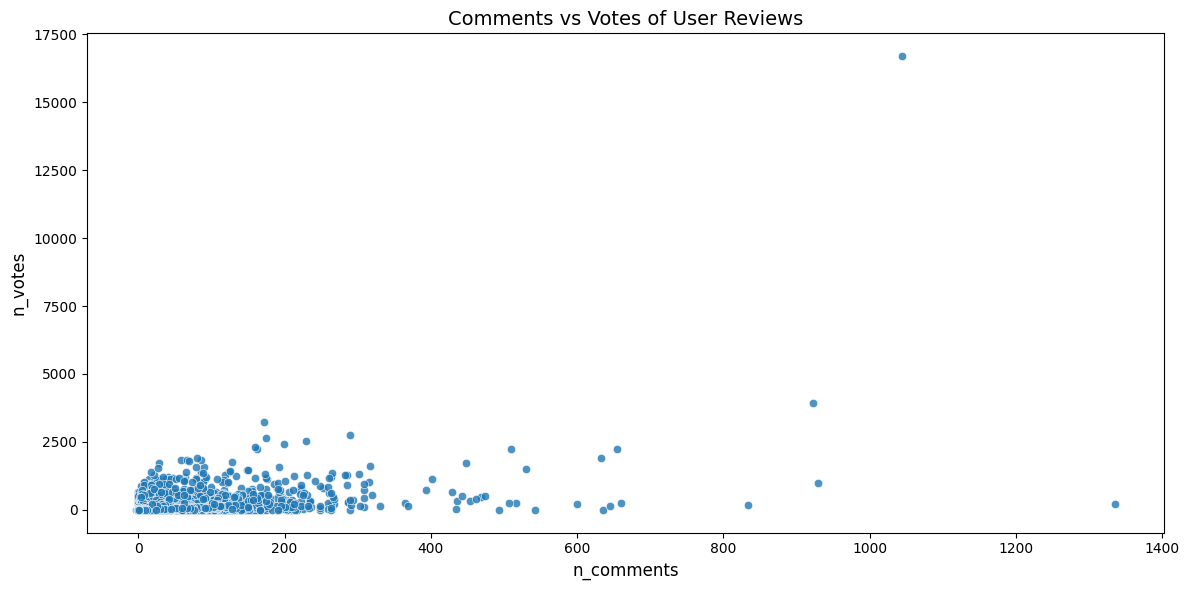

In [12]:
# --- scripts/08_scatterplot.py ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_rules = pd.read_csv('../data/03_extractedreviews.csv')

plt.figure(figsize=(12, 6))

scatter = sns.scatterplot(
    data=df_rules,
    x='n_comments',
    y='n_votes',
    palette='viridis', 
    sizes=(50, 200),
    alpha=0.8
)

plt.title('Comments vs Votes of User Reviews', fontsize=14)
plt.xlabel('n_comments', fontsize=12)
plt.ylabel('n_votes', fontsize=12)

plt.tight_layout()
plt.savefig('../docs/scatterplot_extractedreviews.png')
plt.show()

# Conclusion & Next Steps
Milestone 2 has successfully established the data pipeline and validated genre associations. 

**Upcoming Milestone 3 Plan:**
* **K-Means Clustering:** Segmenting users into "Reader Personas" based on rating variance and review frequency.
* **LDA Topic Modeling:** Extracting qualitative themes from the `review_text` to understand what drives "helpful" votes.

## Milestone 3 



In [13]:


df_reviews = pd.read_csv('../data/03_extractedreviews.csv')

print("Aggregating user metrics")
user_features = df_reviews.groupby('user_id').agg(
    review_frequency=('book_id', 'count'), # How many books did they rate?
    avg_rating=('rating', 'mean'),         # Are they a harsh critic or generous?
    rating_variance=('rating', 'var')      # Do they use the whole 1-5 scale?
).reset_index()

user_features['rating_variance'] = user_features['rating_variance'].fillna(0) # users w/ only one review has a rating variance of NaN
user_features = user_features[user_features['review_frequency'] >= 3] # filter out outliers that only have 3

print(f"Extracted features for {len(user_features)} unique readers.")
display(user_features.head())

Aggregating user metrics
Extracted features for 235885 unique readers.


,user_id,review_frequency,avg_rating,rating_variance
0,00000377eea48021d3002730d56aca9a,3,4.333333,0.333333
1,00009e46d18f223a82b22da38586b605,65,3.384615,0.834135
2,0000c3d51aa099745e93a4e99c4856c8,198,3.767677,1.448290
4,000157a6f8331e9c9a21252e1fee91d1,14,3.928571,1.148352
6,000192962b87d560f00b06fdcbd71681,13,4.692308,0.230769


Calculating inertia for Elbow Plot...


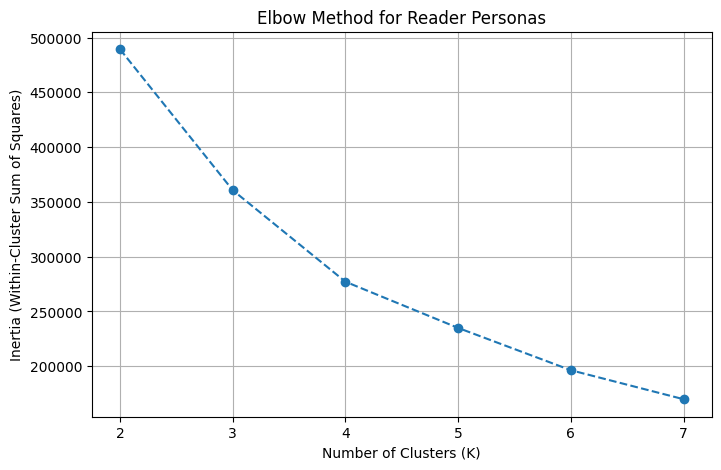

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

features_to_clus = ['review_frequency', 'avg_rating', 'rating_variance']
X = user_features[features_to_clus]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
K_range = range(2,8)

print("Calculating inertia for Elbow Plot...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# 4. Plot the Elbow
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Reader Personas')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()




### K means silhouette Score

This cell measures how well each data point fits into its assigned cluster compared to other clusters. It provides a quantitative way to assess the quality of your K-Means results beyond the visual "bend" of an elbow plot.  


A score of 0.50 shows that our clusters are distinct separate groups. The data shows that the 4 clusters have the best balance between cohesion and separation. 

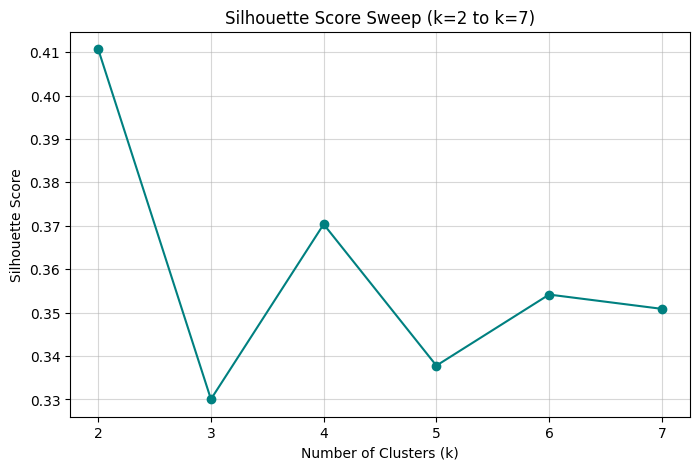

In [26]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 8) 
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    # Calculate using a random sample of 10,000 points to drastically speed up execution
    score = silhouette_score(X_scaled, cluster_labels, sample_size=10000, random_state=42)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o', linestyle='-', color='teal')
plt.title('Silhouette Score Sweep (k=2 to k=7)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True, alpha=0.5)
plt.show()

In [19]:
OPTIMAL_K = 4 # based on where elbow bends in graph

final_kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)

user_features['Cluster'] = final_kmeans.fit_predict(X_scaled)

persona_profiles = user_features.groupby('Cluster').agg(
    User_Count=('user_id', 'count'),
    review_frequency=('review_frequency', 'mean'),
    Overall_Avg_Rating=('avg_rating', 'mean'),
    rating_variance=('rating_variance', 'mean')
).round(2)

print(f"--- Reader Persona Profiles (K={OPTIMAL_K}) ---")
display(persona_profiles)

--- Reader Persona Profiles (K=4) ---


,User_Count,review_frequency,Overall_Avg_Rating,rating_variance
Cluster,,,,
0,98723,28.86,3.44,1.50
1,20180,10.02,2.91,4.63
2,111363,19.53,4.43,0.58
3,5619,390.79,3.76,1.12


## Preprocessing for LDA Analysis

Previously our datasets were cleaned up for K-means clustering and FP-Growth algorithms however for an LDA analysis we need to pre-process the dataset for the goodreads_reviews_dedup.tar.gz. Which is what this next section will do


In [21]:
import pandas as pd


try:
    nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])
except:
    import os
    os.system('python -m spacy download en_core_web_sm')
    nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])

    
def preprocess(text):
    # 1. Lowercase and remove non-alphabetic characters/extra spaces
    text = re.sub(r'[^a-zA-Z\s]', '', str(text).lower())

    doc = nlp(text)

    # 3. Lemmatize and remove stopwords + short words (under 3 chars)
    # We remove common words like 'book', 'read', 'story' which are noise in this dataset
    custom_stopwords = {'book', 'read', 'story', 'author', 'reading', 'get', 'like'}

    tokens = [
        token.lemma_ for token in doc 
        if not token.is_stop 
        and token.lemma_ not in custom_stopwords 
        and len(token.lemma_) > 2
    ]
    
    return tokens
    

In [22]:
df_reviews = pd.read_csv('../data/03_extractedreviews.csv').sample(20000, random_state=42) #load extracted reviews (starting with a sample of 10k - 50k 

print("Starting text preprocessing")
df_reviews['tokens'] = df_reviews['review_snippet'].apply(preprocess)

# Remove any reviews that became empty after cleaning
df_reviews = df_reviews[df_reviews['tokens'].map(len) > 0]


print(f"Preprocessed {len(df_reviews)} reviews.")
df_reviews[['review_snippet', 'tokens']].head()

Starting text preprocessing
Preprocessed 19807 reviews.


,review_snippet,tokens
6596927,"Clare is a wonderful, engaging YA author. I th...","[clare, wonderful, engage, think, late, series..."
7236932,Rating overview Writing: Story: Characte...,"[rating, overview, write, character, overall, ..."
4106604,"Once again, Fforde has provided a totally insa...","[fforde, provide, totally, insane, totally, fu..."
3619791,Confusing then interesting. An intriguing way ...,"[confuse, interesting, intriguing, way, tell]"
3336095,This was one of the books I closed with reluct...,"[close, reluctance, not, want, end, good, way,..."


## LDA 

Now after preprocessing it is time to train the LDA model. We convert our tokens from the previous cells and and builds the LDA model

In [23]:


# 1. Join tokens back into strings (Sklearn expects sentences/strings, not lists)
text_data = df_reviews['tokens'].apply(lambda x: ' '.join(x))

# 2. Vectorize the text (Bag of Words)
# min_df=10: word must appear in 10+ reviews
# max_df=0.5: ignore words appearing in more than 50% of reviews
vectorizer = CountVectorizer(min_df=10, max_df=0.5)
data_vectorized = vectorizer.fit_transform(text_data)

# 3. Build the LDA Model
# n_components=10: We look for 10 themes/topics
lda_model = LatentDirichletAllocation(n_components=40, random_state=42, n_jobs=-1)
lda_output = lda_model.fit_transform(data_vectorized)

print("LDA Model Training Complete!")

LDA Model Training Complete!


In [24]:
def print_top_words(model, vectorizer, n_top_words):
    #after running the LDA model we can print out theIn oThe topics of the reviews we trained on
    feature_names = vectorizer.get_feature_names_out()
    for topic_idx, topic in enumerate(model.components_):
        message = f"Topic #{topic_idx}: "
        message += " ".join([feature_names[i]
                             for i in topic.argsort()[:-n_top_words - 1:-1]])
        print(message)

print_top_words(lda_model, vectorizer, 10)

Topic #0: feel high school begin happy harry not potter jane expectation
Topic #1: sure say let real point che view use non start
Topic #2: start amazing right line fiction lose writer science interest surprised
Topic #3: not know miss usually want write care find tear hook
Topic #4: spoiler alert long actually reread reason complete contain enjoy reality
Topic #5: year great funny old finally glad ago hear maybe entertaining
Topic #6: good character main learn pretty way para enjoy slightly narrator
Topic #7: historical excited disappointed hand base true stand consider piece course
Topic #8: pretty tale write classic woman beautifully previous scifi enjoy mix
Topic #9: want listen relationship dan list audiobook play yang ini cliffhanger
Topic #10: bad tell try happen boy draw stop title hilarious sister
Topic #11: day night king describe travel week thi setting stephen creepy
Topic #12: okay honestly brilliant feeling short strong hat sit goodread damn
Topic #13: beautiful ending wo

In [25]:
# 1. Assign the dominant topic (the one with the highest probability) to each review
df_reviews['dominant_topic'] = np.argmax(lda_output, axis=1)

# 2. Aggregate the engagement metrics by topic
topic_analysis = df_reviews.groupby('dominant_topic').agg({
    'n_votes': 'mean',
    'n_comments': 'mean',
    'review_snippet': 'count'
}).rename(columns={'review_snippet': 'review_count'})

# 3. Sort by votes to see which topics drive engagement
print("--- Average Engagement per Topic ---")
display(topic_analysis.sort_values(by='n_votes', ascending=False))

--- Average Engagement per Topic ---


,n_votes,n_comments,review_count
dominant_topic,,,
17,4.993548,1.064516,465
11,2.988679,0.732075,265
10,2.414439,0.534759,374
39,2.358173,0.442308,416
31,2.208238,0.395881,437
19,2.167151,0.546512,688
28,1.928395,0.600000,405
8,1.717105,0.364035,456
27,1.706052,0.471182,694
